In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'C:\Users\fathi\OneDrive\Desktop\5thsem_OJT\project_diabetes\data\processed\project_databetes_cleaned.csv',parse_dates=["last_checkup_date"])

In [3]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1


In [4]:
df.shape

(950, 14)

In [5]:
df.dtypes

patient_id                      str
age                           int64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
dtype: object

create and age band feature

In [6]:
df['age band']=pd.cut(df['age'],
bins=[0,35,55,120],
labels=['under 35','35-55','over 55'])

In [7]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age band
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,over 55
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,35-55
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,35-55
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,over 55
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,over 55


create a bmi category feature

In [8]:
df['bmi category']=pd.cut(df['bmi'],
bins=[0,18.5,25,30,100],
labels=['underweights','normal','over weight','obese'])

In [9]:
df['bmi category'].value_counts()

bmi category
obese           553
over weight     235
normal          124
underweights     38
Name: count, dtype: int64

create glucose band feature

In [10]:
df['glucose category']=pd.cut(df['glucose'],
bins=[0,100,126,300],
labels=['normal','prediabetic','diabetic'])

In [11]:
df['glucose category'].value_counts()

glucose category
diabetic       349
prediabetic    337
normal         264
Name: count, dtype: int64

create an insulin to glucose ratio feature

In [12]:
df['insulin_glucose_ratio']=df['insulin']/df['glucose']

In [13]:
df['insulin_glucose_ratio'].head()

0    1.000000
1    0.274510
2    1.119718
3    1.024793
4    0.943925
Name: insulin_glucose_ratio, dtype: float64

check the ratio the impossible values

In [14]:
df['insulin_glucose_ratio'].describe()

count    950.000000
mean       1.213108
std        1.179183
min        0.054348
25%        0.726708
50%        1.052139
75%        1.512831
max       22.745763
Name: insulin_glucose_ratio, dtype: float64

In [15]:
np.isinf(df['insulin_glucose_ratio']).sum()

np.int64(0)

create a pregnancies per of age feature 

In [16]:
df['pregnancies_age_rate']=df['pregnancies']/df['age']

In [17]:
df['pregnancies_age_rate'].describe()

count    950.000000
mean       0.042787
std        0.067440
min        0.000000
25%        0.000000
50%        0.000000
75%        0.072661
max        0.380952
Name: pregnancies_age_rate, dtype: float64

create a days since last checkup feature

In [18]:
referene_date=df['last_checkup_date'].max()

In [19]:
referene_date


Timestamp('2024-12-28 00:00:00')

create  a days_since _last

In [20]:
df['days_since_checkup']=(referene_date-df['last_checkup_date']).dt.days

In [21]:
df['days_since_checkup']

0      618
1      239
2      539
3      258
4      336
      ... 
945    407
946    588
947    570
948    206
949    445
Name: days_since_checkup, Length: 950, dtype: int64

create a categorical combination feature

In [22]:
df['smoker_activity']=df['physical_activity']+'/'+df['smoker']

check the compination feature balance

In [23]:
df['smoker_activity'].value_counts

<bound method IndexOpsMixin.value_counts of 0       Unknown/NO
1       Medium/YES
2      Low/UNKNOWN
3      Unknown/YES
4           Low/NO
          ...     
945     Medium/YES
946        Low/YES
947         Low/NO
948        High/NO
949      Medium/NO
Name: smoker_activity, Length: 950, dtype: str>

inventory evry new columns

In [24]:
# activity smoker = physical_activity + smoker
# age band = age
# bmi category = bmi
# glucose category = glucose
# insulin glucose ratio = insulin/glucose
# pregnancy rate = pregnancies/age
# days since checkup = reference_date - last_checkup_date

In [25]:
df.shape

(950, 21)

explority analysis


re_run the groupp comparison on orginal  features

In [26]:
numeric_cols=['age','pregnancies','glucose','blood_pressure','skin_thickness','insulin','bmi','diabetes_pedigree']
df.groupby('outcome')[numeric_cols].mean()
          
 

,age,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree
outcome,,,,,,,,
0,47.874446,1.828656,112.220027,72.350074,26.370753,131.490399,30.941359,0.441821
1,54.798535,1.915751,131.868081,71.930403,26.047619,132.388278,32.516850,0.511564


re_run the groupp comparison on   features

In [27]:
engineer_numeric=['days_since_checkup','insulin_glucose_ratio','pregnancies_age_rate']
df.groupby('outcome')[engineer_numeric].mean()

,days_since_checkup,insulin_glucose_ratio,pregnancies_age_rate
outcome,,,
0,350.304284,1.271066,0.044392
1,366.534799,1.069380,0.038809


rank everythink together

In [28]:
group_means =df.groupby('outcome')[numeric_cols + engineer_numeric].mean().T
group_means['gap']=(group_means[1]-group_means[0]).abs()
group_means.sort_values('gap',ascending=False)

outcome,0,1,gap
glucose,112.220027,131.868081,19.648054
days_since_checkup,350.304284,366.534799,16.230515
age,47.874446,54.798535,6.924089
bmi,30.941359,32.516850,1.575491
insulin,131.490399,132.388278,0.897880
blood_pressure,72.350074,71.930403,0.419671
skin_thickness,26.370753,26.047619,0.323134
insulin_glucose_ratio,1.271066,1.069380,0.201686
pregnancies,1.828656,1.915751,0.087095
diabetes_pedigree,0.441821,0.511564,0.069743


state the new   top three

In [29]:
#glucose,days_since_checkup,age

cross tabulate the age band againts outcome

In [40]:
pd.crosstab(df['age band'], df['outcome'], normalize='index')

outcome,0,1
age band,,
35-55,0.766871,0.233129
over 55,0.612903,0.387097
under 35,0.789683,0.210317


cross tabulate the bmi category outcome

In [31]:
pd.crosstab(df['bmi category'],df['outcome'],normalize='index')

outcome,0,1
bmi category,,
underweights,0.763158,0.236842
normal,0.750000,0.250000
over weight,0.770213,0.229787
obese,0.676311,0.323689


cross tabulate the  glucose category  againts outcome

In [32]:
pd.crosstab(df['glucose category'],df['outcome'],normalize='index')

outcome,0,1
glucose category,,
normal,0.901515,0.098485
prediabetic,0.715134,0.284866
diabetic,0.567335,0.432665


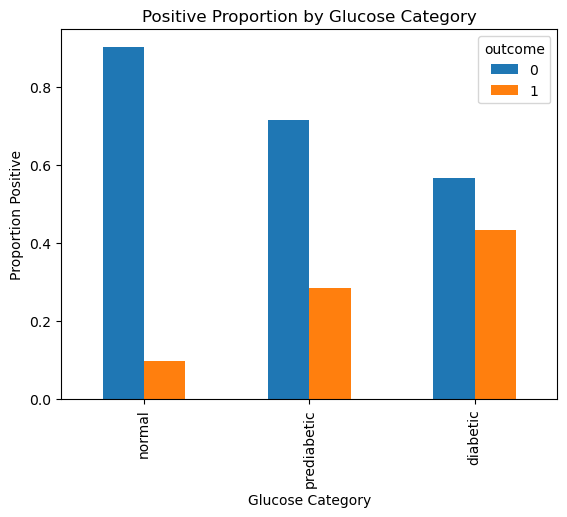

In [33]:
ax = pd.crosstab(df['glucose category'], df['outcome'], normalize='index')

ax.plot(kind='bar')

plt.xlabel('Glucose Category')
plt.ylabel('Proportion Positive')
plt.title('Positive Proportion by Glucose Category')

plt.show()

In [34]:
df.to_csv(r'C:\Users\fathi\OneDrive\Desktop\5thsem_OJT\project_diabetes\data\processed\risvana_p1w2_features.csv',index=False)

In [42]:
df=pd.read_csv(r'C:\Users\fathi\OneDrive\Desktop\5thsem_OJT\project_diabetes\data\processed\risvana_p1w2_features.csv')